# Урок 4.3. Градиентный бустинг с нуля на Python

**Интерактивная версия:** `lessons/lesson_4_3/web/index.html`

Реализация лежит в `lessons/lesson_4_3/examples/gbm_from_scratch.py` — импортируем её и проверяем:
корректность (сверка с scikit-learn), скорость, поэтапные прогнозы; затем делаем потери подключаемыми.

In [1]:
import sys
import time
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))
sys.path.insert(0, str(ROOT / "lessons" / "lesson_4_3" / "examples"))

import inspect
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from gbcourse import datasets, GBRegressor
from gbcourse.plotting import use_course_style
from gbm_from_scratch import Tree, GradientBoosting, best_split

use_course_style()
print(inspect.getsource(GradientBoosting))

class GradientBoosting:
    """Бустинг с квадратичными потерями: F0 = среднее, деревья на остатках, шаг ν."""

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_leaf=1):
        self.M, self.nu, self.max_depth, self.min_leaf = n_estimators, learning_rate, max_depth, min_leaf

    def fit(self, X, y):
        self.f0 = y.mean()
        F = np.full(len(y), self.f0)
        self.trees = []
        for _ in range(self.M):
            tree = Tree(self.max_depth, self.min_leaf).fit(X, y - F)
            F += self.nu * tree.predict(X)
            self.trees.append(tree)
        return self

    def predict(self, X, n_trees=None):
        F = np.full(len(X), self.f0)
        for tree in self.trees[:n_trees]:
            F += self.nu * tree.predict(X)
        return F



## 1. Корректность

In [2]:
X, y = datasets.friedman1(n=500, noise=1.0, seed=43)
X_tr, X_val, y_tr, y_val = datasets.train_test_split(X, y, test_size=0.3, seed=0)
ours = GradientBoosting(n_estimators=200, learning_rate=0.1, max_depth=3).fit(X_tr, y_tr)
sk = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3).fit(X_tr, y_tr)
lib = GBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3).fit(X_tr, y_tr)
print("на обучении: наша − sklearn:", np.abs(ours.predict(X_tr) - sk.predict(X_tr)).max())
print("на обучении: наша − gbcourse:", np.abs(ours.predict(X_tr) - lib.predict(X_tr)).max())
print("на валидации: наша − sklearn:", np.abs(ours.predict(X_val) - sk.predict(X_val)).max())
for name, m in [("наша", ours), ("sklearn", sk), ("gbcourse", lib)]:
    print(f"MSE на валидации, {name:8s}: {np.mean((y_val - m.predict(X_val)) ** 2):.4f}")

на обучении: наша − sklearn: 1.0658141036401503e-14
на обучении: наша − gbcourse: 1.0658141036401503e-14
на валидации: наша − sklearn: 0.7227073521066139
MSE на валидации, наша    : 3.3208
MSE на валидации, sklearn : 3.2581
MSE на валидации, gbcourse: 3.2950


На обучении модели совпадают до 1e-14, а на новых точках — не совсем. Причина — **ничьи**: в маленьких
узлах несколько признаков делят обучающие объекты одинаково и дают один и тот же выигрыш. Какой признак
выбрать, каждая реализация решает по-своему (sklearn — в случайном порядке признаков, мы — первый
по номеру, а крошечные ошибки округления разных формул выигрыша сдвигают выбор). На обучающих данных
такие деревья неразличимы, на новых — чуть-чуть отличаются. Качество при этом одинаковое.

## 2. Скорость

In [3]:
for name, make in [("с нуля", lambda: GradientBoosting(200, 0.1, 3)), ("gbcourse", lambda: GBRegressor(n_estimators=200, max_depth=3)),
                   ("sklearn", lambda: GradientBoostingRegressor(n_estimators=200, max_depth=3))]:
    t0 = time.perf_counter()
    make().fit(X_tr, y_tr)
    print(f"{name:9s}: {time.perf_counter() - t0:.2f} с")

с нуля   : 0.24 с


gbcourse : 0.45 с
sklearn  : 0.20 с


scikit-learn написан на Cython и в десятки раз быстрее; наши реализации — для понимания.

## 3. Кривые обучения и валидации

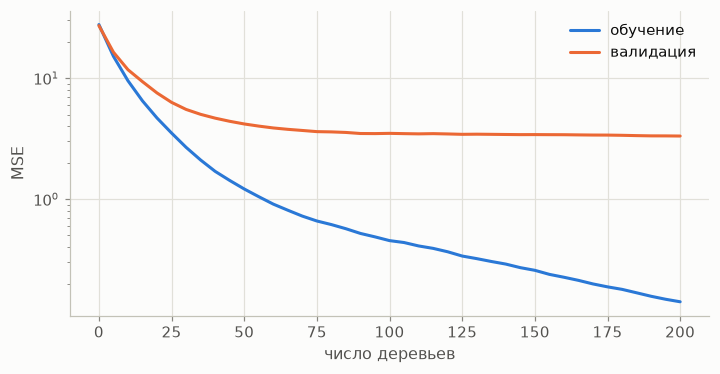

In [4]:
ms = list(range(0, 201, 5))
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(ms, [np.mean((y_tr - ours.predict(X_tr, m)) ** 2) for m in ms], label="обучение")
ax.plot(ms, [np.mean((y_val - ours.predict(X_val, m)) ** 2) for m in ms], label="валидация")
ax.set(xlabel="число деревьев", ylabel="MSE", yscale="log")
ax.legend()
plt.show()

## 4. Подключаемые потери: L2 и L1 на данных с выбросами

In [5]:
Xo, yo = datasets.regression_1d(kind="wave", n=300, noise=0.3, seed=4, outliers=0.08)
Xa, Xb, ya, yb = datasets.train_test_split(Xo, yo, test_size=0.3, seed=0)
for loss in ("squared", "absolute"):
    m = GBRegressor(loss=loss, n_estimators=300, learning_rate=0.1, max_depth=2).fit(Xa, ya)
    print(f"{loss:9s}: MAE на валидации {np.mean(np.abs(yb - m.predict(Xb))):.3f}")

squared  : MAE на валидации 1.031
absolute : MAE на валидации 0.712


## Упражнения

1. Добавьте в `GradientBoosting` параметр `subsample` (обучать каждое дерево на случайной доле объектов).
2. Добавьте раннюю остановку: `fit(X, y, eval_set, patience)` прекращает обучение, если валидация не улучшалась `patience` итераций.
3. Ускорьте `best_split`, отсортировав признаки один раз на всё дерево.

Решения: `python lessons/lesson_4_3/exercises/solutions.py`.